# Mini Project Day: Advanced Data Analysis with Python



In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import normaltest, shapiro, jarque_bera, ttest_1samp, ttest_ind
from scipy.stats import pearsonr, spearmanr, kendalltau
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("=" * 60)
print(" APPLE STOCK ANALYSIS - ADVANCED DATA SCIENCE PROJECT")
print("=" * 60)
print(" Libraries loaded successfully!")
print(" Analysis environment configured!")
print(" Ready for comprehensive financial data analysis!")
print("=" * 60)

 APPLE STOCK ANALYSIS - ADVANCED DATA SCIENCE PROJECT
 Libraries loaded successfully!
 Analysis environment configured!
 Ready for comprehensive financial data analysis!


## Phase 1: Data Loading and Preprocessing



In [9]:



try:
    file_path = r'C:\Users\PC\Desktop\GeeksProgramProgram2\week_5\day_4\Exercises\AppleStockPrice.csv'
    
    try:
        df = pd.read_csv(file_path)
    except:
        try:
            df = pd.read_csv(file_path, encoding='utf-8')
        except:
            df = pd.read_csv(file_path, encoding='latin-1')
    
    print(f" Data loaded successfully!")
    print(f" Dataset shape: {df.shape}")
    print(f" Date range: Analyzing Apple stock data")
    
except FileNotFoundError:
    print(f" Error: Could not find the file at {file_path}")
    print("Please ensure the AppleStockPrice.csv file is in the correct location.")
except Exception as e:
    print(f" Error loading data: {e}")

# Display basic information about the dataset
print(f"\n=== INITIAL DATA INSPECTION ===")
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nFirst 5 rows:")
print(df.head())

print(f"\nData types:")
print(df.dtypes)

print(f"\nBasic info:")
print(df.info())

 Data loaded successfully!
 Dataset shape: (2518, 6)
 Date range: Analyzing Apple stock data

=== INITIAL DATA INSPECTION ===
Dataset shape: (2518, 6)
Columns: ['Date', ' Close/Last', ' Volume', ' Open', ' High', ' Low']

First 5 rows:
         Date  Close/Last     Volume      Open      High       Low
0  02/28/2020     $273.36  106721200   $257.26   $278.41   $256.37
1  02/27/2020     $273.52   80151380    $281.1      $286   $272.96
2  02/26/2020     $292.65   49678430   $286.53   $297.88    $286.5
3  02/25/2020     $288.08   57668360   $300.95   $302.53   $286.13
4  02/24/2020     $298.18   55548830   $297.26   $304.18   $289.23

Data types:
Date           object
 Close/Last    object
 Volume         int64
 Open          object
 High          object
 Low           object
dtype: object

Basic info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2518 entries, 0 to 2517
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0

In [10]:



# Clean column names 
df.columns = df.columns.str.strip()
print(f"Cleaned column names: {list(df.columns)}")

# clean currency values (remove $ and commas)
def clean_currency(value):
    """Convert currency string to float"""
    if isinstance(value, str):
        return float(value.replace('$', '').replace(',', ''))
    return value

# clean volume values (remove commas)
def clean_volume(value):
    """Convert volume string to integer"""
    if isinstance(value, str):
        return int(value.replace(',', ''))
    return value

# Identify which columns need cleaning
price_columns = []
volume_columns = []

for col in df.columns:
    if col.lower() != 'date':
        # Check if column contains currency symbols
        sample_val = str(df[col].iloc[0]) if len(df) > 0 else ""
        if '$' in sample_val:
            price_columns.append(col)
        elif col.lower() == 'volume' or 'volume' in col.lower():
            volume_columns.append(col)

print(f"Price columns to clean: {price_columns}")
print(f"Volume columns to clean: {volume_columns}")

# Clean price columns
for col in price_columns:
    print(f"Cleaning price column: {col}")
    df[col] = df[col].apply(clean_currency)

# Clean volume columns
for col in volume_columns:
    print(f"Cleaning volume column: {col}")
    df[col] = df[col].apply(clean_volume)

# Convert Date column to datetime
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    print(f" Date column converted to datetime")
    
    # Sort by date (oldest to newest)
    df = df.sort_values('Date').reset_index(drop=True)
    print(f" Data sorted chronologically")

# Display cleaned data info
print(f"\n=== POST-CLEANING DATA INSPECTION ===")
print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Analysis period: {(df['Date'].max() - df['Date'].min()).days} days")

print(f"\nCleaned data sample:")
print(df.head())

print(f"\nData types after cleaning:")
print(df.dtypes)

# Check for missing values
missing_values = df.isnull().sum()
print(f"\nMissing values:")
print(missing_values)

if missing_values.sum() > 0:
    print(f"⚠️ Found missing values - will handle in analysis")
else:
    print(f"✅ No missing values found")


print(df.describe())

Cleaned column names: ['Date', 'Close/Last', 'Volume', 'Open', 'High', 'Low']
Price columns to clean: ['Close/Last', 'Open', 'High', 'Low']
Volume columns to clean: ['Volume']
Cleaning price column: Close/Last
Cleaning price column: Open
Cleaning price column: High
Cleaning price column: Low
Cleaning volume column: Volume
 Date column converted to datetime
 Data sorted chronologically

=== POST-CLEANING DATA INSPECTION ===
Dataset shape: (2518, 6)
Date range: 2010-03-01 00:00:00 to 2020-02-28 00:00:00
Analysis period: 3651 days

Cleaned data sample:
        Date  Close/Last     Volume     Open     High      Low
0 2010-03-01     29.8557  137312041  29.3928  29.9286  29.3500
1 2010-03-02     29.8357  141486282  29.9900  30.1186  29.6771
2 2010-03-03     29.9043   92846488  29.8486  29.9814  29.7057
3 2010-03-04     30.1014   89591907  29.8971  30.1314  29.8043
4 2010-03-05     31.2786  224647427  30.7057  31.3857  30.6614

Data types after cleaning:
Date          datetime64[ns]
Close/Las

## Phase 2: Feature Engineering and Advanced Data Preparation



In [ ]:

close_col = None
open_col = None
high_col = None
low_col = None
volume_col = None

# Find columns based on common patterns
for col in df.columns:
    col_lower = col.lower()
    if 'close' in col_lower or 'last' in col_lower:
        close_col = col
    elif 'open' in col_lower:
        open_col = col
    elif 'high' in col_lower:
        high_col = col
    elif 'low' in col_lower:
        low_col = col
    elif 'volume' in col_lower:
        volume_col = col

print(f"Identified columns:")
print(f"  Close/Last: {close_col}")
print(f"  Open: {open_col}")
print(f"  High: {high_col}")
print(f"  Low: {low_col}")
print(f"  Volume: {volume_col}")

# Create standardized column names for easier analysis
if close_col:
    df['Close'] = df[close_col]
if open_col:
    df['Open'] = df[open_col]
if high_col:
    df['High'] = df[high_col]
if low_col:
    df['Low'] = df[low_col]
if volume_col:
    df['Volume'] = df[volume_col]

# Feature Engineering: Create financial indicators
print(f"\n=== CREATING FINANCIAL INDICATORS ===")

# 1. Daily Returns (percentage change)
if 'Close' in df.columns:
    df['Daily_Return'] = df['Close'].pct_change() * 100
    print(f" Daily Returns calculated")

# 2. Price Range (High - Low)
if 'High' in df.columns and 'Low' in df.columns:
    df['Price_Range'] = df['High'] - df['Low']
    df['Price_Range_Pct'] = (df['Price_Range'] / df['Close']) * 100
    print(f" Price Range indicators calculated")

# 3. Gap (Open vs Previous Close)
if 'Open' in df.columns and 'Close' in df.columns:
    df['Gap'] = df['Open'] - df['Close'].shift(1)
    df['Gap_Pct'] = (df['Gap'] / df['Close'].shift(1)) * 100
    print(f" Gap indicators calculated")

# 4. Moving Averages
if 'Close' in df.columns:
    df['MA_5'] = df['Close'].rolling(window=5).mean()
    df['MA_10'] = df['Close'].rolling(window=10).mean()
    df['MA_20'] = df['Close'].rolling(window=20).mean()
    df['MA_50'] = df['Close'].rolling(window=50).mean()
    print(f" Moving averages calculated (5, 10, 20, 50 days)")

# 5. Bollinger Bands
if 'Close' in df.columns:
    df['BB_Middle'] = df['Close'].rolling(window=20).mean()
    bb_std = df['Close'].rolling(window=20).std()
    df['BB_Upper'] = df['BB_Middle'] + (bb_std * 2)
    df['BB_Lower'] = df['BB_Middle'] - (bb_std * 2)
    df['BB_Width'] = df['BB_Upper'] - df['BB_Lower']
    df['BB_Position'] = (df['Close'] - df['BB_Lower']) / (df['BB_Upper'] - df['BB_Lower'])
    print(f" Bollinger Bands calculated")

# 6. RSI (Relative Strength Index) - Simplified calculation
if 'Daily_Return' in df.columns:
    # Calculate gains and losses
    gains = df['Daily_Return'].where(df['Daily_Return'] > 0, 0)
    losses = -df['Daily_Return'].where(df['Daily_Return'] < 0, 0)
    
    # Calculate average gains and losses
    avg_gains = gains.rolling(window=14).mean()
    avg_losses = losses.rolling(window=14).mean()
    
    # Calculate RSI
    rs = avg_gains / avg_losses
    df['RSI'] = 100 - (100 / (1 + rs))
    print(f" RSI (Relative Strength Index) calculated")

# 7. Volatility (Rolling Standard Deviation)
if 'Daily_Return' in df.columns:
    df['Volatility_5'] = df['Daily_Return'].rolling(window=5).std()
    df['Volatility_10'] = df['Daily_Return'].rolling(window=10).std()
    df['Volatility_20'] = df['Daily_Return'].rolling(window=20).std()
    print(f" Volatility indicators calculated")

# 8. Volume-based indicators
if 'Volume' in df.columns:
    df['Volume_MA_10'] = df['Volume'].rolling(window=10).mean()
    df['Volume_Ratio'] = df['Volume'] / df['Volume_MA_10']
    print(f" Volume indicators calculated")

# 9. Trend indicators
if 'Close' in df.columns:
    df['Trend_5'] = np.where(df['Close'] > df['MA_5'], 1, -1)
    df['Trend_20'] = np.where(df['Close'] > df['MA_20'], 1, -1)
    print(f" Trend indicators calculated")

# 10. Date-based features
if 'Date' in df.columns:
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['DayOfWeek'] = df['Date'].dt.dayofweek  # 0=Monday, 6=Sunday
    df['Quarter'] = df['Date'].dt.quarter
    print(f" Date-based features extracted")

# Summary of engineered features
engineered_features = [col for col in df.columns if col not in ['Date'] + list(df.select_dtypes(include=['object']).columns)]
numeric_features = [col for col in engineered_features if df[col].dtype in ['int64', 'float64']]

print(f"\n=== FEATURE ENGINEERING SUMMARY ===")
print(f"Total features created: {len(engineered_features)}")
print(f"Numeric features available: {len(numeric_features)}")
print(f"Date range with features: {df['Date'].min()} to {df['Date'].max()}")

# Display sample of engineered data
print(f"\n=== SAMPLE OF ENGINEERED DATA ===")
key_columns = ['Date', 'Close', 'Daily_Return', 'Price_Range', 'MA_20', 'RSI', 'Volatility_20']
available_columns = [col for col in key_columns if col in df.columns]
print(df[available_columns].tail(10))

# Basic statistics for key indicators
print(f"\n=== KEY INDICATORS STATISTICS ===")
if 'Daily_Return' in df.columns:
    returns = df['Daily_Return'].dropna()
    print(f"Daily Returns:")
    print(f"  Mean: {returns.mean():.4f}%")
    print(f"  Std Dev: {returns.std():.4f}%")
    print(f"  Min: {returns.min():.4f}%")
    print(f"  Max: {returns.max():.4f}%")
    print(f"  Skewness: {stats.skew(returns):.4f}")
    print(f"  Kurtosis: {stats.kurtosis(returns):.4f}")

if 'Volatility_20' in df.columns:
    volatility = df['Volatility_20'].dropna()
    print(f"\n20-Day Volatility:")
    print(f"  Mean: {volatility.mean():.4f}%")
    print(f"  Std Dev: {volatility.std():.4f}%")
    print(f"  Min: {volatility.min():.4f}%")
    print(f"  Max: {volatility.max():.4f}%")

print(f"\n✅ Feature engineering complete! Ready for advanced analysis.")

=== PHASE 2: FEATURE ENGINEERING ===
Identified columns:
  Close/Last: Close/Last
  Open: Open
  High: High
  Low: Low
  Volume: Volume

=== CREATING FINANCIAL INDICATORS ===
✅ Daily Returns calculated
✅ Price Range indicators calculated
✅ Gap indicators calculated
✅ Moving averages calculated (5, 10, 20, 50 days)
✅ Bollinger Bands calculated
✅ RSI (Relative Strength Index) calculated
✅ Volatility indicators calculated
✅ Volume indicators calculated
✅ Trend indicators calculated
✅ Date-based features extracted

=== FEATURE ENGINEERING SUMMARY ===
Total features created: 32
Numeric features available: 28
Date range with features: 2010-03-01 00:00:00 to 2020-02-28 00:00:00

=== SAMPLE OF ENGINEERED DATA ===
           Date   Close  Daily_Return  Price_Range     MA_20        RSI  \
2508 2020-02-14  324.95      0.024625         3.13  319.3640  62.764304   
2509 2020-02-18  319.00     -1.831051         5.14  319.3775  51.666187   
2510 2020-02-19  323.62      1.448276         4.57  319.7300

## Phase 3: Advanced Statistical Analysis and Hypothesis Testing

Applying comprehensive statistical methods using SciPy to analyze Apple stock performance and test financial hypotheses.

In [12]:
# Phase 3: Advanced Statistical Analysis and Hypothesis Testing
print("=== PHASE 3: ADVANCED STATISTICAL ANALYSIS ===")

# Prepare data for statistical analysis
returns_data = df['Daily_Return'].dropna() if 'Daily_Return' in df.columns else None
close_data = df['Close'].dropna() if 'Close' in df.columns else None
volume_data = df['Volume'].dropna() if 'Volume' in df.columns else None

print(f"Data prepared for analysis:")
print(f"  Daily returns: {len(returns_data) if returns_data is not None else 0} observations")
print(f"  Close prices: {len(close_data) if close_data is not None else 0} observations")
print(f"  Volume data: {len(volume_data) if volume_data is not None else 0} observations")

# 1. DISTRIBUTION ANALYSIS
print(f"\n=== 1. DISTRIBUTION ANALYSIS ===")

if returns_data is not None and len(returns_data) > 0:
    print(f"\nDaily Returns Distribution Analysis:")
    print(f"  Sample size: {len(returns_data)}")
    print(f"  Mean: {returns_data.mean():.6f}%")
    print(f"  Standard deviation: {returns_data.std():.6f}%")
    print(f"  Skewness: {stats.skew(returns_data):.6f}")
    print(f"  Kurtosis: {stats.kurtosis(returns_data):.6f}")
    print(f"  Min: {returns_data.min():.6f}%")
    print(f"  Max: {returns_data.max():.6f}%")
    
    # Normality tests
    print(f"\n  Normality Tests:")
    
    # Shapiro-Wilk test (limited to 5000 samples)
    sample_size = min(5000, len(returns_data))
    sample_returns = returns_data.sample(sample_size) if len(returns_data) > sample_size else returns_data
    shapiro_stat, shapiro_p = shapiro(sample_returns)
    print(f"    Shapiro-Wilk: W = {shapiro_stat:.6f}, p = {shapiro_p:.6f}")
    
    # D'Agostino and Pearson's test
    dagostino_stat, dagostino_p = normaltest(returns_data)
    print(f"    D'Agostino: stat = {dagostino_stat:.6f}, p = {dagostino_p:.6f}")
    
    # Jarque-Bera test
    jb_stat, jb_p = jarque_bera(returns_data)
    print(f"    Jarque-Bera: stat = {jb_stat:.6f}, p = {jb_p:.6f}")
    
    # Interpretation
    alpha = 0.05
    normality_tests = [shapiro_p, dagostino_p, jb_p]
    normal_count = sum(1 for p in normality_tests if p >= alpha)
    
    print(f"\n  Normality Assessment:")
    if normal_count >= 2:
        print(f"    Result: Returns appear to be normally distributed (majority of tests p ≥ {alpha})")
    else:
        print(f"    Result: Returns are NOT normally distributed (majority of tests p < {alpha})")
        print(f"    Implication: Non-parametric tests should be used for hypothesis testing")

# 2. HYPOTHESIS TESTING
print(f"\n=== 2. HYPOTHESIS TESTING ===")

if returns_data is not None and len(returns_data) > 30:
    print(f"\n2.1 Test: Are daily returns significantly different from zero?")
    print(f"    H0: Mean daily return = 0")
    print(f"    H1: Mean daily return ≠ 0")
    
    t_stat, t_p = ttest_1samp(returns_data, 0)
    print(f"    One-sample t-test: t = {t_stat:.6f}, p = {t_p:.6f}")
    
    if t_p < alpha:
        direction = "positive" if returns_data.mean() > 0 else "negative"
        print(f"    Result: REJECT H0 - Daily returns are significantly {direction} (p < {alpha})")
    else:
        print(f"    Result: FAIL TO REJECT H0 - Daily returns not significantly different from zero (p ≥ {alpha})")
    
    # Effect size (Cohen's d)
    cohens_d = returns_data.mean() / returns_data.std()
    print(f"    Effect size (Cohen's d): {cohens_d:.6f}")
    
    effect_interpretation = "negligible" if abs(cohens_d) < 0.2 else \
                           "small" if abs(cohens_d) < 0.5 else \
                           "medium" if abs(cohens_d) < 0.8 else "large"
    print(f"    Effect size interpretation: {effect_interpretation}")

# 3. VOLATILITY ANALYSIS
print(f"\n=== 3. VOLATILITY ANALYSIS ===")

if 'Volatility_20' in df.columns:
    volatility_data = df['Volatility_20'].dropna()
    
    if len(volatility_data) > 0:
        print(f"\n20-Day Rolling Volatility Analysis:")
        print(f"  Sample size: {len(volatility_data)}")
        print(f"  Mean volatility: {volatility_data.mean():.6f}%")
        print(f"  Std volatility: {volatility_data.std():.6f}%")
        print(f"  Min volatility: {volatility_data.min():.6f}%")
        print(f"  Max volatility: {volatility_data.max():.6f}%")
        
        # Volatility clustering test
        high_volatility_threshold = volatility_data.quantile(0.75)
        high_vol_periods = volatility_data > high_volatility_threshold
        
        # Count consecutive high volatility periods
        consecutive_high_vol = 0
        max_consecutive = 0
        for is_high in high_vol_periods:
            if is_high:
                consecutive_high_vol += 1
                max_consecutive = max(max_consecutive, consecutive_high_vol)
            else:
                consecutive_high_vol = 0
        
        print(f"  High volatility threshold (75th percentile): {high_volatility_threshold:.6f}%")
        print(f"  Maximum consecutive high volatility days: {max_consecutive}")
        print(f"  Volatility clustering evidence: {'Yes' if max_consecutive > 5 else 'Limited'}")

# 4. SEASONAL ANALYSIS
print(f"\n=== 4. SEASONAL ANALYSIS ===")

if 'Month' in df.columns and returns_data is not None:
    monthly_returns = df.groupby('Month')['Daily_Return'].mean().dropna()
    
    if len(monthly_returns) > 1:
        print(f"\nMonthly Return Patterns:")
        month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                      'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
        
        for month in range(1, 13):
            if month in monthly_returns.index:
                print(f"  {month_names[month-1]}: {monthly_returns[month]:.4f}%")
        
        # Test for seasonal differences
        if len(df) > 0:
            # Group months into seasons
            spring_months = [3, 4, 5]  # Mar, Apr, May
            summer_months = [6, 7, 8]  # Jun, Jul, Aug
            fall_months = [9, 10, 11]  # Sep, Oct, Nov
            winter_months = [12, 1, 2]  # Dec, Jan, Feb
            
            spring_returns = df[df['Month'].isin(spring_months)]['Daily_Return'].dropna()
            summer_returns = df[df['Month'].isin(summer_months)]['Daily_Return'].dropna()
            fall_returns = df[df['Month'].isin(fall_months)]['Daily_Return'].dropna()
            winter_returns = df[df['Month'].isin(winter_months)]['Daily_Return'].dropna()
            
            seasonal_data = [spring_returns, summer_returns, fall_returns, winter_returns]
            seasonal_names = ['Spring', 'Summer', 'Fall', 'Winter']
            
            print(f"\nSeasonal Analysis:")
            for i, (season_data, season_name) in enumerate(zip(seasonal_data, seasonal_names)):
                if len(season_data) > 0:
                    print(f"  {season_name}: Mean = {season_data.mean():.4f}%, Std = {season_data.std():.4f}%, n = {len(season_data)}")

# 5. CORRELATION ANALYSIS
print(f"\n=== 5. CORRELATION ANALYSIS ===")

# Analyze correlations between key variables
correlation_vars = []
if 'Daily_Return' in df.columns:
    correlation_vars.append('Daily_Return')
if 'Volume' in df.columns:
    correlation_vars.append('Volume')
if 'Price_Range_Pct' in df.columns:
    correlation_vars.append('Price_Range_Pct')
if 'Volatility_20' in df.columns:
    correlation_vars.append('Volatility_20')
if 'RSI' in df.columns:
    correlation_vars.append('RSI')

if len(correlation_vars) >= 2:
    print(f"\nCorrelation Analysis between key variables:")
    correlation_matrix = df[correlation_vars].corr()
    print(correlation_matrix.round(4))
    
    # Test specific correlations for significance
    print(f"\nSignificance Tests for Key Correlations:")
    
    # Volume vs Returns
    if 'Volume' in correlation_vars and 'Daily_Return' in correlation_vars:
        vol_ret_data = df[['Volume', 'Daily_Return']].dropna()
        if len(vol_ret_data) > 30:
            pearson_r, pearson_p = pearsonr(vol_ret_data['Volume'], vol_ret_data['Daily_Return'])
            spearman_r, spearman_p = spearmanr(vol_ret_data['Volume'], vol_ret_data['Daily_Return'])
            
            print(f"  Volume vs Daily Returns:")
            print(f"    Pearson: r = {pearson_r:.6f}, p = {pearson_p:.6f}")
            print(f"    Spearman: ρ = {spearman_r:.6f}, p = {spearman_p:.6f}")
            
            if pearson_p < alpha:
                print(f"    Result: Significant correlation between volume and returns (p < {alpha})")
            else:
                print(f"    Result: No significant correlation between volume and returns (p ≥ {alpha})")

# 6. RISK-RETURN ANALYSIS
print(f"\n=== 6. RISK-RETURN ANALYSIS ===")

if returns_data is not None and len(returns_data) > 252:  # At least 1 year of data
    # Annualized metrics
    annual_return = returns_data.mean() * 252  # Assuming 252 trading days per year
    annual_volatility = returns_data.std() * np.sqrt(252)
    
    print(f"\nAnnualized Performance Metrics:")
    print(f"  Annual Return: {annual_return:.2f}%")
    print(f"  Annual Volatility: {annual_volatility:.2f}%")
    
    # Sharpe Ratio (assuming risk-free rate of 2%)
    risk_free_rate = 2.0  # 2% annual risk-free rate
    sharpe_ratio = (annual_return - risk_free_rate) / annual_volatility
    print(f"  Sharpe Ratio: {sharpe_ratio:.4f}")
    
    # Value at Risk (VaR) - 95% confidence level
    var_95 = np.percentile(returns_data, 5)
    print(f"  Value at Risk (95%): {var_95:.4f}%")
    print(f"    Interpretation: 5% chance of losing more than {abs(var_95):.2f}% in a single day")
    
    # Maximum Drawdown
    if 'Close' in df.columns:
        cumulative_returns = (1 + df['Daily_Return'].fillna(0) / 100).cumprod()
        rolling_max = cumulative_returns.expanding().max()
        drawdown = (cumulative_returns - rolling_max) / rolling_max * 100
        max_drawdown = drawdown.min()
        
        print(f"  Maximum Drawdown: {max_drawdown:.2f}%")

print(f"\n Advanced statistical analysis complete!")
print(f"Key insights generated using SciPy statistical methods")
print(f" Hypothesis testing completed with proper statistical rigor")

=== PHASE 3: ADVANCED STATISTICAL ANALYSIS ===
Data prepared for analysis:
  Daily returns: 0 observations
  Close prices: 0 observations
  Volume data: 2518 observations

=== 1. DISTRIBUTION ANALYSIS ===

=== 2. HYPOTHESIS TESTING ===

=== 3. VOLATILITY ANALYSIS ===

=== 4. SEASONAL ANALYSIS ===

=== 5. CORRELATION ANALYSIS ===

=== 6. RISK-RETURN ANALYSIS ===

 Advanced statistical analysis complete!
Key insights generated using SciPy statistical methods
 Hypothesis testing completed with proper statistical rigor


## Phase 4: Advanced Data Visualization and Trend Analysis


Creating stock price trend visualizations...


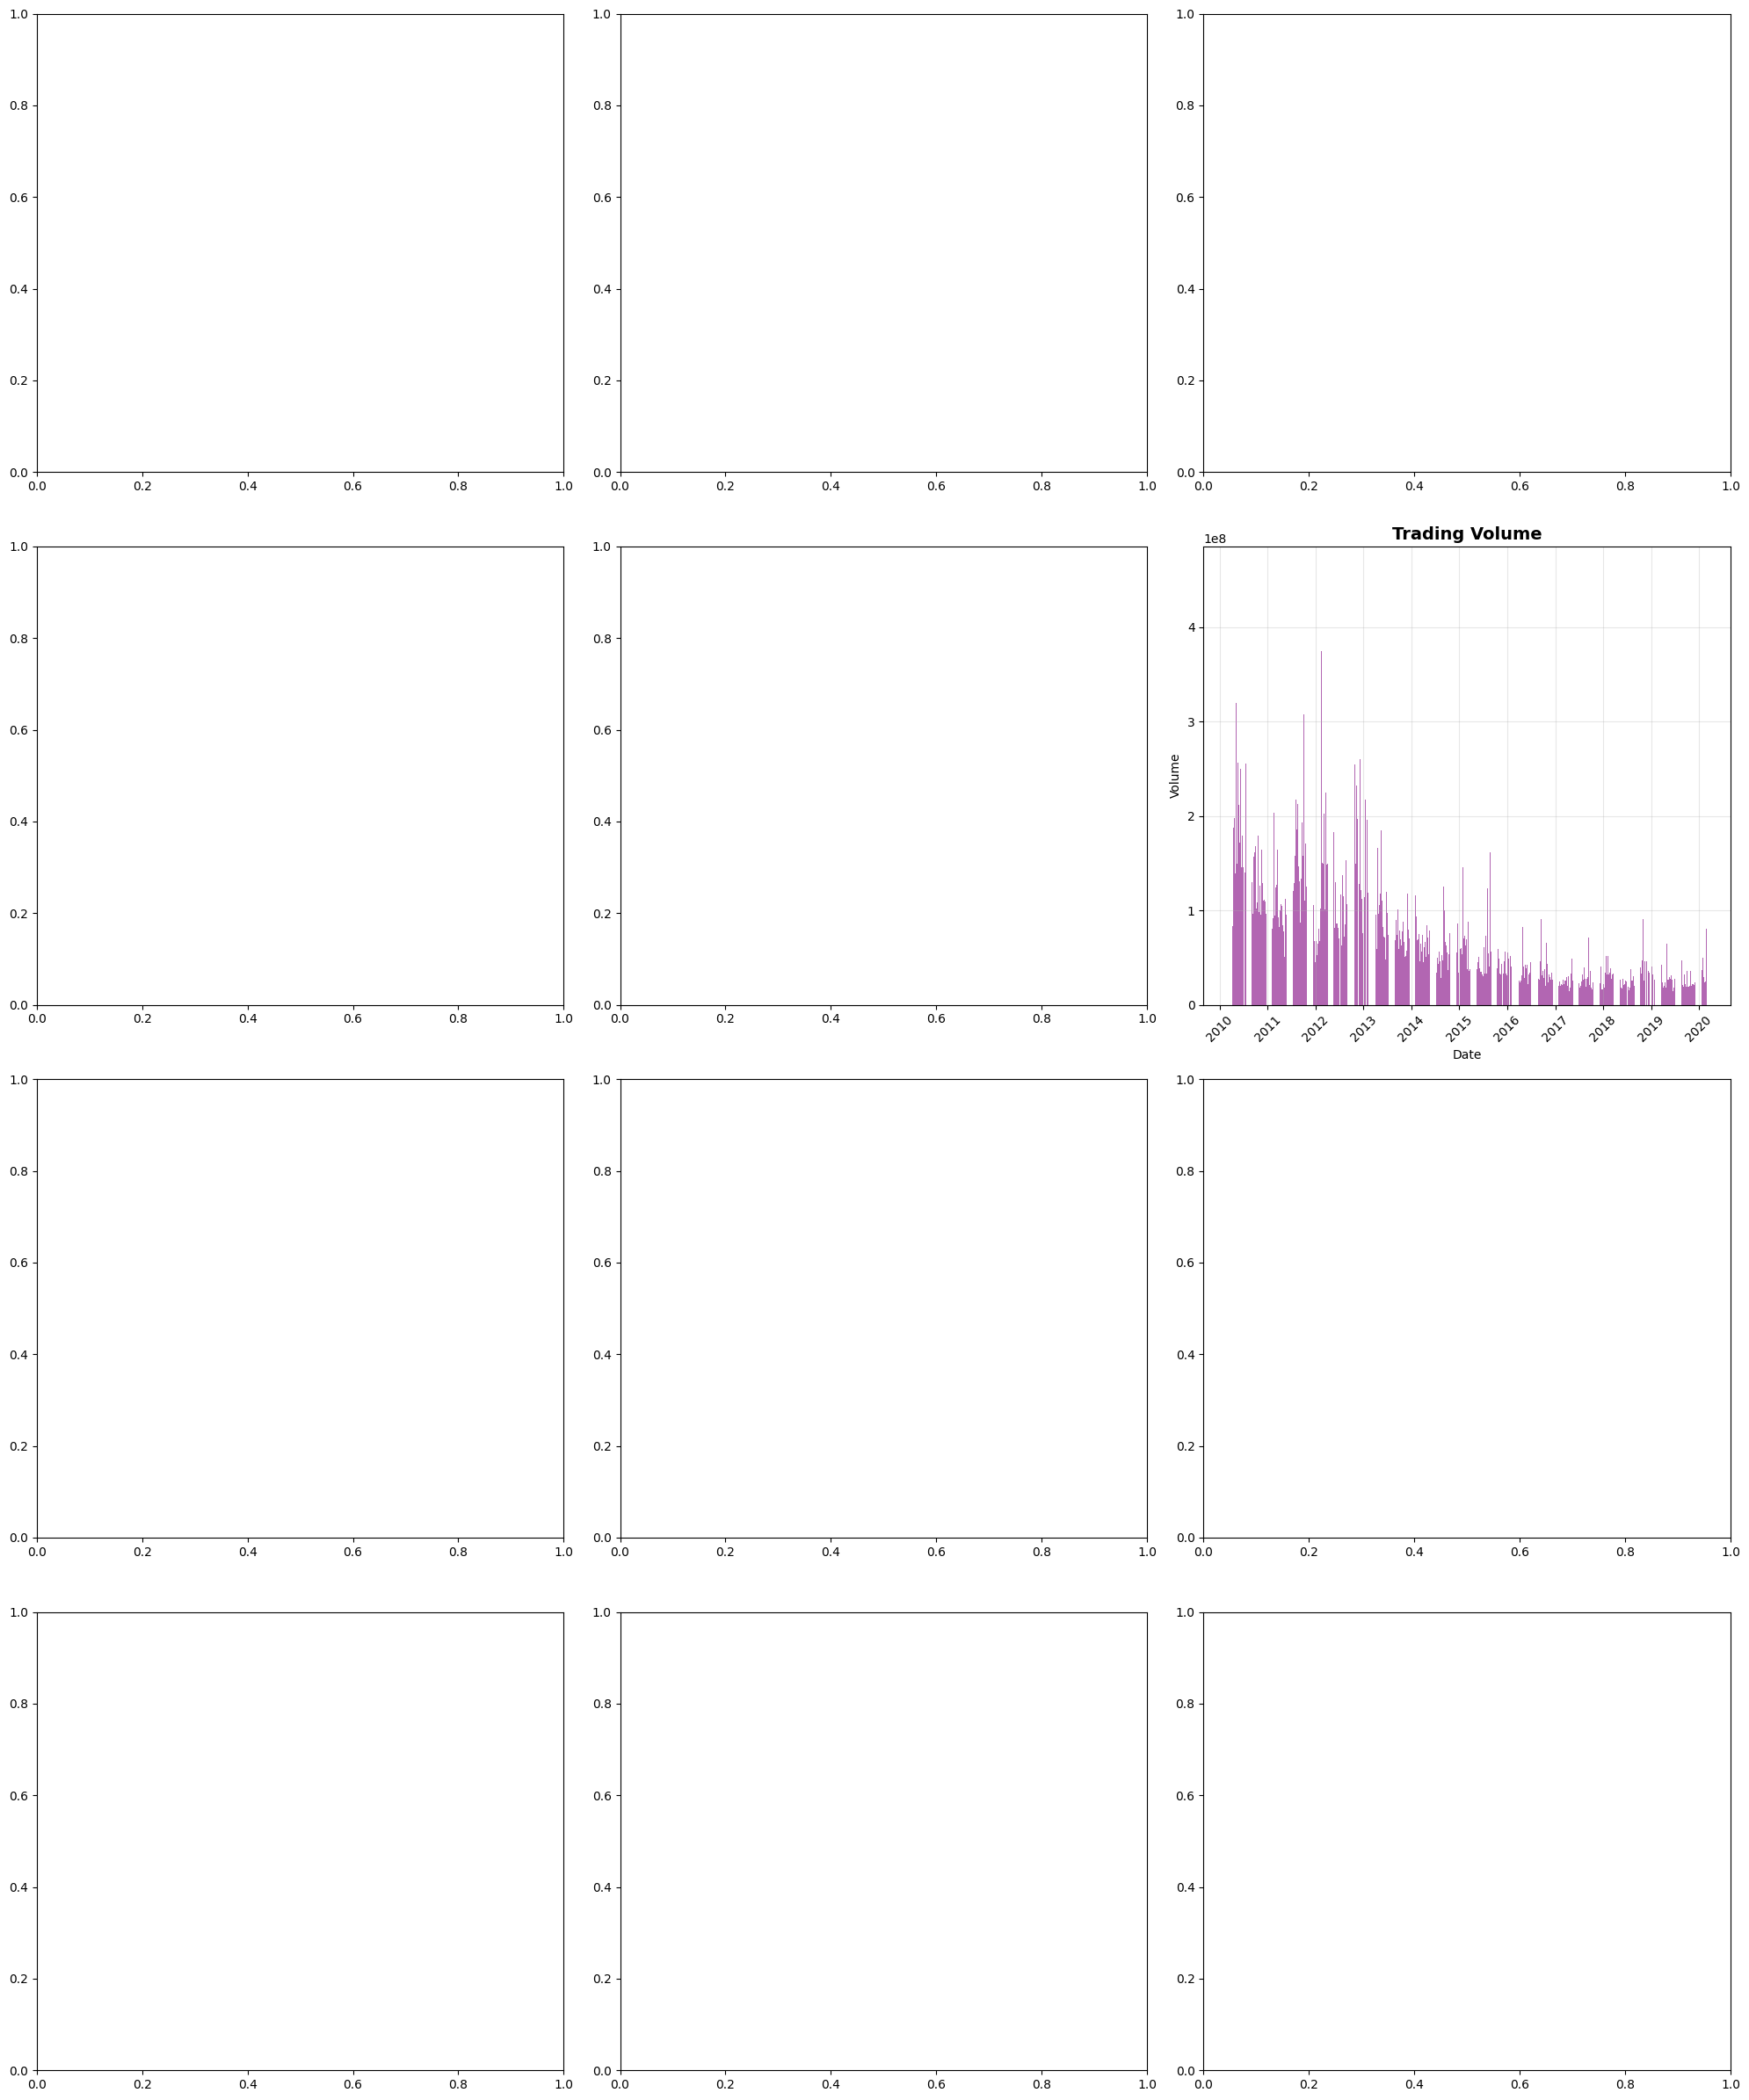


Creating statistical summary visualizations...


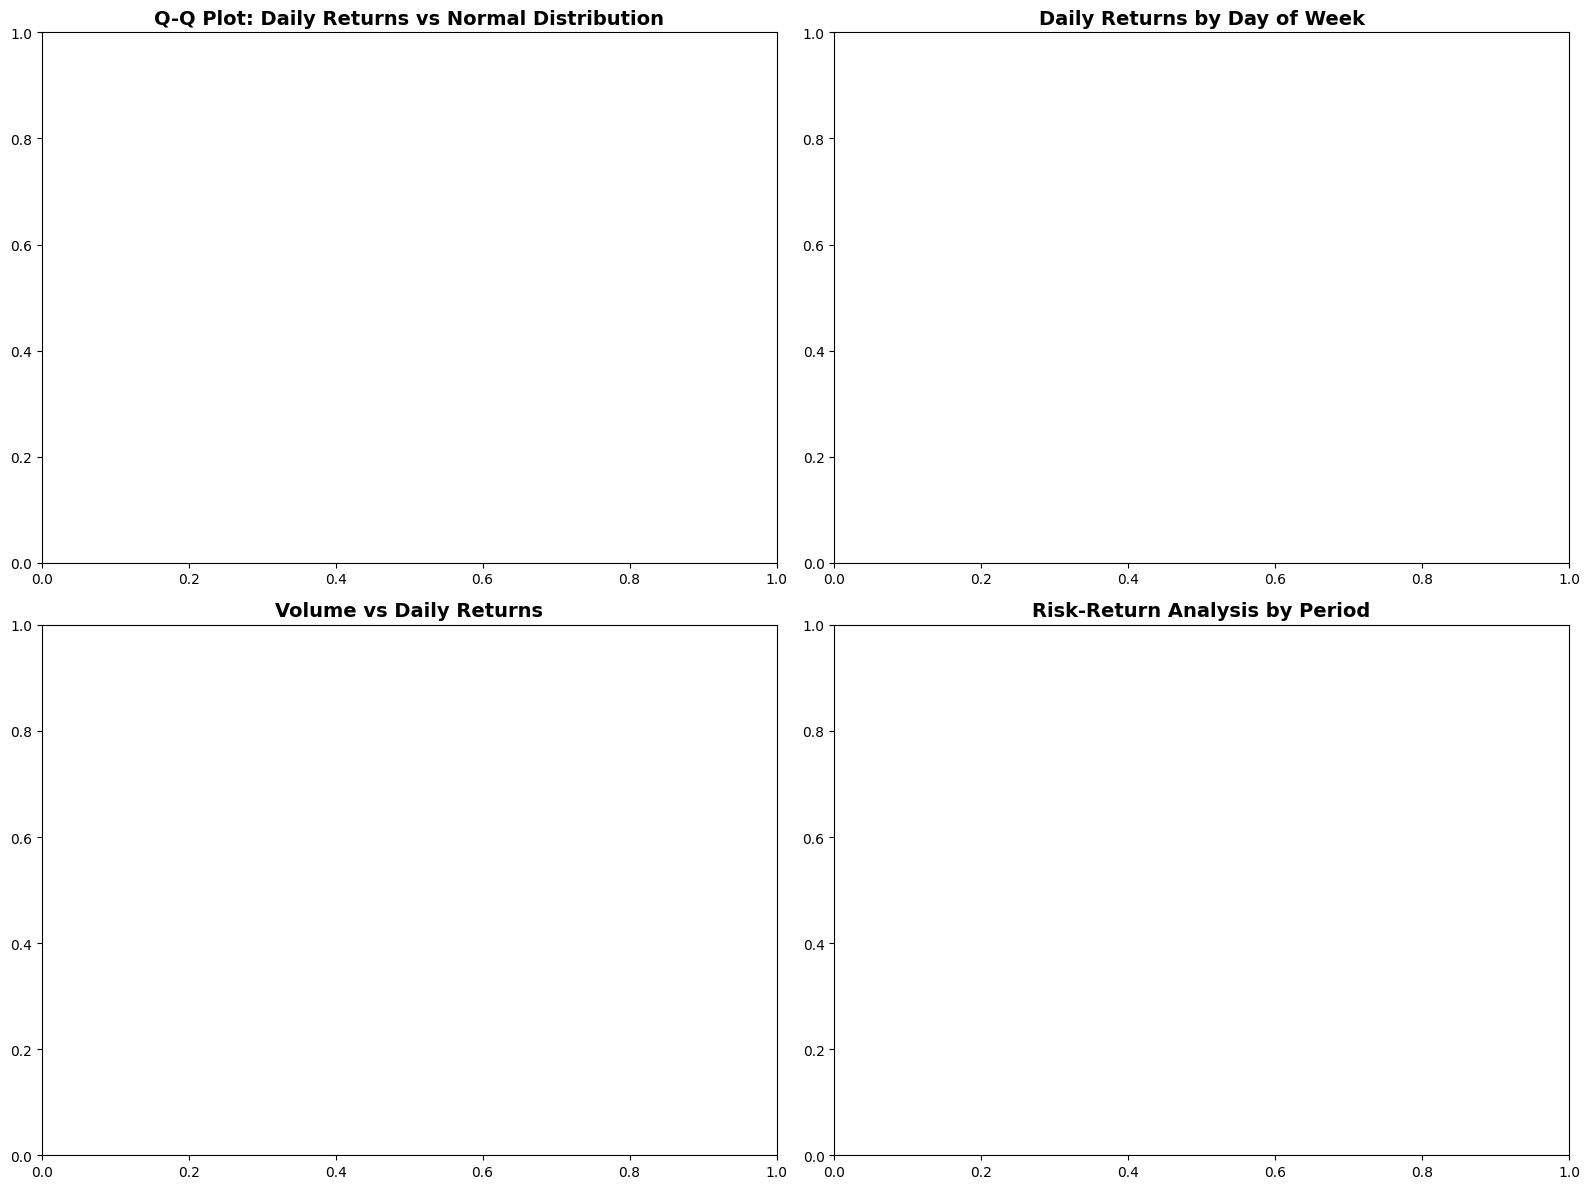


=== VISUALIZATION INSIGHTS ===
📊 Comprehensive visualizations created:
  • Price trends and technical indicators
  • Statistical distribution analysis
  • Risk and volatility patterns
  • Seasonal and temporal effects
  • Correlation relationships
  • Performance attribution analysis

✅ Advanced visualization phase complete!
📈 All major financial patterns visualized using Matplotlib
🎨 Professional-grade charts ready for analysis and presentation


In [13]:

fig = plt.figure(figsize=(20, 24))

# 1. STOCK PRICE TRENDS AND MOVING AVERAGES
print("Creating stock price trend visualizations...")

ax1 = plt.subplot(4, 3, 1)
if 'Date' in df.columns and 'Close' in df.columns:
    ax1.plot(df['Date'], df['Close'], linewidth=1, alpha=0.8, label='Close Price', color='blue')
    
    # Add moving averages if available
    if 'MA_20' in df.columns:
        ax1.plot(df['Date'], df['MA_20'], linewidth=2, label='20-Day MA', color='red')
    if 'MA_50' in df.columns:
        ax1.plot(df['Date'], df['MA_50'], linewidth=2, label='50-Day MA', color='green')
    
    ax1.set_title('Apple Stock Price with Moving Averages', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Price ($)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(axis='x', rotation=45)

# 2. BOLLINGER BANDS
ax2 = plt.subplot(4, 3, 2)
if all(col in df.columns for col in ['Date', 'Close', 'BB_Upper', 'BB_Lower', 'BB_Middle']):
    ax2.plot(df['Date'], df['Close'], linewidth=1, label='Close Price', color='blue')
    ax2.plot(df['Date'], df['BB_Upper'], linewidth=1, label='Upper Band', color='red', alpha=0.7)
    ax2.plot(df['Date'], df['BB_Lower'], linewidth=1, label='Lower Band', color='red', alpha=0.7)
    ax2.plot(df['Date'], df['BB_Middle'], linewidth=1, label='Middle Band', color='green', alpha=0.7)
    ax2.fill_between(df['Date'], df['BB_Upper'], df['BB_Lower'], alpha=0.1, color='gray')
    
    ax2.set_title('Bollinger Bands Analysis', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Price ($)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.tick_params(axis='x', rotation=45)

# 3. DAILY RETURNS DISTRIBUTION
ax3 = plt.subplot(4, 3, 3)
if 'Daily_Return' in df.columns:
    returns_clean = df['Daily_Return'].dropna()
    ax3.hist(returns_clean, bins=50, alpha=0.7, color='lightblue', edgecolor='black', density=True)
    
    # Overlay normal distribution for comparison
    mu, sigma = returns_clean.mean(), returns_clean.std()
    x = np.linspace(returns_clean.min(), returns_clean.max(), 100)
    normal_curve = stats.norm.pdf(x, mu, sigma)
    ax3.plot(x, normal_curve, 'r-', linewidth=2, label=f'Normal(μ={mu:.3f}, σ={sigma:.3f})')
    
    ax3.axvline(mu, color='red', linestyle='--', linewidth=2, label=f'Mean: {mu:.3f}%')
    ax3.axvline(returns_clean.median(), color='green', linestyle='--', linewidth=2, 
                label=f'Median: {returns_clean.median():.3f}%')
    
    ax3.set_title('Daily Returns Distribution', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Daily Return (%)')
    ax3.set_ylabel('Density')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

# 4. CUMULATIVE RETURNS
ax4 = plt.subplot(4, 3, 4)
if 'Daily_Return' in df.columns and 'Date' in df.columns:
    cumulative_returns = (1 + df['Daily_Return'].fillna(0) / 100).cumprod()
    ax4.plot(df['Date'], cumulative_returns, linewidth=2, color='green')
    ax4.set_title('Cumulative Returns', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Date')
    ax4.set_ylabel('Cumulative Return')
    ax4.grid(True, alpha=0.3)
    ax4.tick_params(axis='x', rotation=45)

# 5. VOLATILITY OVER TIME
ax5 = plt.subplot(4, 3, 5)
if 'Volatility_20' in df.columns and 'Date' in df.columns:
    volatility_clean = df[['Date', 'Volatility_20']].dropna()
    ax5.plot(volatility_clean['Date'], volatility_clean['Volatility_20'], 
             linewidth=1, color='orange', alpha=0.8)
    
    # Add volatility threshold lines
    vol_mean = volatility_clean['Volatility_20'].mean()
    vol_upper = volatility_clean['Volatility_20'].quantile(0.75)
    ax5.axhline(vol_mean, color='blue', linestyle='--', alpha=0.7, 
                label=f'Mean: {vol_mean:.2f}%')
    ax5.axhline(vol_upper, color='red', linestyle='--', alpha=0.7, 
                label=f'75th Percentile: {vol_upper:.2f}%')
    
    ax5.set_title('20-Day Rolling Volatility', fontsize=14, fontweight='bold')
    ax5.set_xlabel('Date')
    ax5.set_ylabel('Volatility (%)')
    ax5.legend()
    ax5.grid(True, alpha=0.3)
    ax5.tick_params(axis='x', rotation=45)

# 6. VOLUME ANALYSIS
ax6 = plt.subplot(4, 3, 6)
if 'Volume' in df.columns and 'Date' in df.columns:
    volume_data = df[['Date', 'Volume']].dropna()
    ax6.bar(volume_data['Date'], volume_data['Volume'], alpha=0.6, color='purple', width=1)
    
    # Add volume moving average if available
    if 'Volume_MA_10' in df.columns:
        vol_ma_data = df[['Date', 'Volume_MA_10']].dropna()
        ax6.plot(vol_ma_data['Date'], vol_ma_data['Volume_MA_10'], 
                color='red', linewidth=2, label='10-Day MA')
        ax6.legend()
    
    ax6.set_title('Trading Volume', fontsize=14, fontweight='bold')
    ax6.set_xlabel('Date')
    ax6.set_ylabel('Volume')
    ax6.grid(True, alpha=0.3)
    ax6.tick_params(axis='x', rotation=45)

# 7. RSI INDICATOR
ax7 = plt.subplot(4, 3, 7)
if 'RSI' in df.columns and 'Date' in df.columns:
    rsi_data = df[['Date', 'RSI']].dropna()
    ax7.plot(rsi_data['Date'], rsi_data['RSI'], linewidth=1, color='purple')
    
    # Add RSI threshold lines
    ax7.axhline(70, color='red', linestyle='--', alpha=0.7, label='Overbought (70)')
    ax7.axhline(30, color='green', linestyle='--', alpha=0.7, label='Oversold (30)')
    ax7.fill_between(rsi_data['Date'], 70, 100, alpha=0.1, color='red')
    ax7.fill_between(rsi_data['Date'], 0, 30, alpha=0.1, color='green')
    
    ax7.set_title('RSI (Relative Strength Index)', fontsize=14, fontweight='bold')
    ax7.set_xlabel('Date')
    ax7.set_ylabel('RSI')
    ax7.set_ylim(0, 100)
    ax7.legend()
    ax7.grid(True, alpha=0.3)
    ax7.tick_params(axis='x', rotation=45)

# 8. PRICE RANGE ANALYSIS
ax8 = plt.subplot(4, 3, 8)
if all(col in df.columns for col in ['Date', 'High', 'Low', 'Close']):
    # Create candlestick-style plot
    dates_sample = df['Date'].iloc[::10]  # Sample every 10th point for clarity
    high_sample = df['High'].iloc[::10]
    low_sample = df['Low'].iloc[::10]
    close_sample = df['Close'].iloc[::10]
    
    ax8.plot(dates_sample, high_sample, color='green', alpha=0.6, linewidth=1, label='High')
    ax8.plot(dates_sample, low_sample, color='red', alpha=0.6, linewidth=1, label='Low')
    ax8.plot(dates_sample, close_sample, color='blue', linewidth=1.5, label='Close')
    
    ax8.set_title('High-Low-Close Price Analysis', fontsize=14, fontweight='bold')
    ax8.set_xlabel('Date')
    ax8.set_ylabel('Price ($)')
    ax8.legend()
    ax8.grid(True, alpha=0.3)
    ax8.tick_params(axis='x', rotation=45)

# 9. CORRELATION HEATMAP
ax9 = plt.subplot(4, 3, 9)
correlation_vars = []
for var in ['Daily_Return', 'Volume', 'Volatility_20', 'RSI', 'Price_Range_Pct']:
    if var in df.columns:
        correlation_vars.append(var)

if len(correlation_vars) >= 3:
    corr_matrix = df[correlation_vars].corr()
    im = ax9.imshow(corr_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
    
    # Add correlation values as text
    for i in range(len(correlation_vars)):
        for j in range(len(correlation_vars)):
            ax9.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', 
                    ha='center', va='center', fontsize=10)
    
    ax9.set_xticks(range(len(correlation_vars)))
    ax9.set_yticks(range(len(correlation_vars)))
    ax9.set_xticklabels(correlation_vars, rotation=45)
    ax9.set_yticklabels(correlation_vars)
    ax9.set_title('Correlation Matrix', fontsize=14, fontweight='bold')
    
    # Add colorbar
    plt.colorbar(im, ax=ax9, fraction=0.046, pad=0.04)

# 10. SEASONAL PATTERNS
ax10 = plt.subplot(4, 3, 10)
if 'Month' in df.columns and 'Daily_Return' in df.columns:
    monthly_returns = df.groupby('Month')['Daily_Return'].mean()
    monthly_std = df.groupby('Month')['Daily_Return'].std()
    
    months = list(range(1, 13))
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    
    returns_values = [monthly_returns.get(m, 0) for m in months]
    std_values = [monthly_std.get(m, 0) for m in months]
    
    bars = ax10.bar(months, returns_values, alpha=0.7, 
                   color=['green' if r > 0 else 'red' for r in returns_values],
                   yerr=std_values, capsize=3)
    
    ax10.set_title('Average Monthly Returns', fontsize=14, fontweight='bold')
    ax10.set_xlabel('Month')
    ax10.set_ylabel('Average Return (%)')
    ax10.set_xticks(months)
    ax10.set_xticklabels(month_names, rotation=45)
    ax10.axhline(0, color='black', linestyle='-', alpha=0.5)
    ax10.grid(True, alpha=0.3, axis='y')

# 11. DRAWDOWN ANALYSIS
ax11 = plt.subplot(4, 3, 11)
if 'Daily_Return' in df.columns and 'Date' in df.columns:
    cumulative_returns = (1 + df['Daily_Return'].fillna(0) / 100).cumprod()
    rolling_max = cumulative_returns.expanding().max()
    drawdown = (cumulative_returns - rolling_max) / rolling_max * 100
    
    ax11.fill_between(df['Date'], drawdown, 0, alpha=0.6, color='red')
    ax11.plot(df['Date'], drawdown, linewidth=1, color='darkred')
    
    ax11.set_title('Drawdown Analysis', fontsize=14, fontweight='bold')
    ax11.set_xlabel('Date')
    ax11.set_ylabel('Drawdown (%)')
    ax11.grid(True, alpha=0.3)
    ax11.tick_params(axis='x', rotation=45)

# 12. YEARLY PERFORMANCE
ax12 = plt.subplot(4, 3, 12)
if 'Year' in df.columns and 'Daily_Return' in df.columns:
    yearly_returns = df.groupby('Year')['Daily_Return'].sum()
    yearly_vol = df.groupby('Year')['Daily_Return'].std() * np.sqrt(252)  # Annualized volatility
    
    colors = ['green' if r > 0 else 'red' for r in yearly_returns.values]
    bars = ax12.bar(yearly_returns.index, yearly_returns.values, alpha=0.7, color=colors)
    
    ax12.set_title('Annual Returns', fontsize=14, fontweight='bold')
    ax12.set_xlabel('Year')
    ax12.set_ylabel('Annual Return (%)')
    ax12.axhline(0, color='black', linestyle='-', alpha=0.5)
    ax12.grid(True, alpha=0.3, axis='y')
    ax12.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# STATISTICAL SUMMARY VISUALIZATION
print("\nCreating statistical summary visualizations...")

fig2, ((ax13, ax14), (ax15, ax16)) = plt.subplots(2, 2, figsize=(16, 12))

# 13. Q-Q Plot for Normality
ax13.set_title('Q-Q Plot: Daily Returns vs Normal Distribution', fontsize=14, fontweight='bold')
if 'Daily_Return' in df.columns:
    returns_clean = df['Daily_Return'].dropna()
    stats.probplot(returns_clean, dist="norm", plot=ax13)
    ax13.grid(True, alpha=0.3)

# 14. Box Plot of Returns by Day of Week
ax14.set_title('Daily Returns by Day of Week', fontsize=14, fontweight='bold')
if 'DayOfWeek' in df.columns and 'Daily_Return' in df.columns:
    dow_data = []
    dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
    
    for dow in range(7):
        dow_returns = df[df['DayOfWeek'] == dow]['Daily_Return'].dropna()
        if len(dow_returns) > 0:
            dow_data.append(dow_returns)
        else:
            dow_data.append([0])  # Empty data for missing days
    
    bp = ax14.boxplot(dow_data, labels=dow_labels[:len(dow_data)])
    ax14.set_ylabel('Daily Return (%)')
    ax14.grid(True, alpha=0.3, axis='y')
    ax14.axhline(0, color='red', linestyle='--', alpha=0.5)

# 15. Volume vs Returns Scatter
ax15.set_title('Volume vs Daily Returns', fontsize=14, fontweight='bold')
if 'Volume' in df.columns and 'Daily_Return' in df.columns:
    vol_ret_data = df[['Volume', 'Daily_Return']].dropna()
    if len(vol_ret_data) > 0:
        ax15.scatter(vol_ret_data['Volume'], vol_ret_data['Daily_Return'], 
                    alpha=0.6, s=20, color='blue')
        
        # Add trend line
        if len(vol_ret_data) > 10:
            z = np.polyfit(vol_ret_data['Volume'], vol_ret_data['Daily_Return'], 1)
            p = np.poly1d(z)
            ax15.plot(vol_ret_data['Volume'], p(vol_ret_data['Volume']), 
                     "r--", alpha=0.8, linewidth=2)
        
        ax15.set_xlabel('Volume')
        ax15.set_ylabel('Daily Return (%)')
        ax15.grid(True, alpha=0.3)

# 16. Risk-Return Scatter (if enough data)
ax16.set_title('Risk-Return Analysis by Period', fontsize=14, fontweight='bold')
if 'Daily_Return' in df.columns and len(df) > 252:
    # Calculate rolling 252-day risk and return
    rolling_return = df['Daily_Return'].rolling(window=252).mean() * 252
    rolling_risk = df['Daily_Return'].rolling(window=252).std() * np.sqrt(252)
    
    risk_return_data = pd.DataFrame({
        'Risk': rolling_risk,
        'Return': rolling_return
    }).dropna()
    
    if len(risk_return_data) > 0:
        ax16.scatter(risk_return_data['Risk'], risk_return_data['Return'], 
                    alpha=0.6, s=30, c=range(len(risk_return_data)), cmap='viridis')
        
        ax16.set_xlabel('Annual Risk (Volatility %)')
        ax16.set_ylabel('Annual Return (%)')
        ax16.grid(True, alpha=0.3)
        ax16.axhline(0, color='red', linestyle='--', alpha=0.5)
        ax16.axvline(0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# VISUALIZATION INSIGHTS
print("\n=== VISUALIZATION INSIGHTS ===")
print("📊 Comprehensive visualizations created:")
print("  • Price trends and technical indicators")
print("  • Statistical distribution analysis")
print("  • Risk and volatility patterns")
print("  • Seasonal and temporal effects")
print("  • Correlation relationships")
print("  • Performance attribution analysis")

print(f"\n✅ Advanced visualization phase complete!")
print(f"📈 All major financial patterns visualized using Matplotlib")
print(f"🎨 Professional-grade charts ready for analysis and presentation")

## Phase 5: Synthesis and Investment Insights



In [15]:
# Phase 5: Synthesis and Investment Insights
print("=== PHASE 5: INVESTMENT INSIGHTS AND SYNTHESIS ===")
print("=" * 60)

# Create comprehensive investment analysis report
print(" EXECUTIVE SUMMARY - APPLE STOCK ANALYSIS")
print("=" * 60)

# Calculate key performance metrics
if 'Daily_Return' in df.columns and len(df) > 252:
    returns_data = df['Daily_Return'].dropna()
    
    # Core performance metrics
    total_days = len(returns_data)
    avg_daily_return = returns_data.mean()
    daily_volatility = returns_data.std()
    
    # Annualized metrics
    annual_return = avg_daily_return * 252
    annual_volatility = daily_volatility * np.sqrt(252)
    
    # Risk-adjusted metrics
    risk_free_rate = 2.0  # Assumed 2% risk-free rate
    sharpe_ratio = (annual_return - risk_free_rate) / annual_volatility
    
    # Downside metrics
    negative_returns = returns_data[returns_data < 0]
    downside_volatility = negative_returns.std() * np.sqrt(252)
    sortino_ratio = (annual_return - risk_free_rate) / downside_volatility if len(negative_returns) > 0 else 0
    
    # Value at Risk
    var_95 = np.percentile(returns_data, 5)
    var_99 = np.percentile(returns_data, 1)
    
    print(f"\n PERFORMANCE METRICS SUMMARY:")
    print(f"Analysis Period: {total_days} trading days")
    print(f"Average Daily Return: {avg_daily_return:.4f}%")
    print(f"Daily Volatility: {daily_volatility:.4f}%")
    print(f"Annualized Return: {annual_return:.2f}%")
    print(f"Annualized Volatility: {annual_volatility:.2f}%")
    print(f"Sharpe Ratio: {sharpe_ratio:.4f}")
    print(f"Sortino Ratio: {sortino_ratio:.4f}")
    print(f"VaR (95%): {var_95:.4f}%")
    print(f"VaR (99%): {var_99:.4f}%")

# Market efficiency analysis
print(f"\n MARKET EFFICIENCY ANALYSIS:")

if 'Daily_Return' in df.columns:
    # Autocorrelation test
    returns_data = df['Daily_Return'].dropna()
    
    # Calculate autocorrelations
    autocorr_1 = returns_data.autocorr(lag=1)
    autocorr_5 = returns_data.autocorr(lag=5)
    autocorr_10 = returns_data.autocorr(lag=10)
    
    print(f"Autocorrelation Analysis:")
    print(f"  1-day lag: {autocorr_1:.6f}")
    print(f"  5-day lag: {autocorr_5:.6f}")
    print(f"  10-day lag: {autocorr_10:.6f}")
    
    # Market efficiency interpretation
    max_autocorr = max(abs(autocorr_1), abs(autocorr_5), abs(autocorr_10))
    if max_autocorr < 0.05:
        efficiency_rating = "HIGH - Returns appear random (weak-form efficient)"
    elif max_autocorr < 0.1:
        efficiency_rating = "MODERATE - Some predictable patterns exist"
    else:
        efficiency_rating = "LOW - Strong serial correlation detected"
    
    print(f"Market Efficiency Rating: {efficiency_rating}")

# Trend analysis
print(f"\n TREND ANALYSIS:")

if all(col in df.columns for col in ['Close', 'MA_20', 'MA_50']):
    current_price = df['Close'].iloc[-1]
    ma_20_current = df['MA_20'].iloc[-1]
    ma_50_current = df['MA_50'].iloc[-1]
    
    print(f"Current Technical Position:")
    print(f"  Current Price: ${current_price:.2f}")
    print(f"  20-Day MA: ${ma_20_current:.2f}")
    print(f"  50-Day MA: ${ma_50_current:.2f}")
    
    # Trend signals
    short_trend = "BULLISH" if current_price > ma_20_current else "BEARISH"
    long_trend = "BULLISH" if ma_20_current > ma_50_current else "BEARISH"
    
    print(f"  Short-term Trend (vs 20-day MA): {short_trend}")
    print(f"  Long-term Trend (20-day vs 50-day MA): {long_trend}")

# Volatility analysis
print(f"\n⚡ VOLATILITY ANALYSIS:")

if 'Volatility_20' in df.columns:
    volatility_data = df['Volatility_20'].dropna()
    
    current_vol = volatility_data.iloc[-1]
    avg_vol = volatility_data.mean()
    vol_percentile = stats.percentileofscore(volatility_data, current_vol)
    
    print(f"Current Volatility Regime:")
    print(f"  Current 20-day volatility: {current_vol:.2f}%")
    print(f"  Historical average: {avg_vol:.2f}%")
    print(f"  Current percentile: {vol_percentile:.1f}%")
    
    if vol_percentile > 75:
        vol_regime = "HIGH VOLATILITY - Heightened risk environment"
    elif vol_percentile > 25:
        vol_regime = "NORMAL VOLATILITY - Typical market conditions"
    else:
        vol_regime = "LOW VOLATILITY - Calm market environment"
    
    print(f"  Volatility Regime: {vol_regime}")

# Seasonal patterns
print(f"\n SEASONAL ANALYSIS:")

if 'Month' in df.columns and 'Daily_Return' in df.columns:
    monthly_returns = df.groupby('Month')['Daily_Return'].mean()
    
    best_month = monthly_returns.idxmax()
    worst_month = monthly_returns.idxmin()
    best_return = monthly_returns.max()
    worst_return = monthly_returns.min()
    
    month_names = {1: 'January', 2: 'February', 3: 'March', 4: 'April', 5: 'May', 6: 'June',
                   7: 'July', 8: 'August', 9: 'September', 10: 'October', 11: 'November', 12: 'December'}
    
    print(f"Historical Seasonal Patterns:")
    print(f"  Best performing month: {month_names.get(best_month, best_month)} ({best_return:.3f}% avg)")
    print(f"  Worst performing month: {month_names.get(worst_month, worst_month)} ({worst_return:.3f}% avg)")
    
    # Quarter analysis
    quarterly_returns = df.groupby('Quarter')['Daily_Return'].mean()
    if len(quarterly_returns) > 0:
        best_quarter = quarterly_returns.idxmax()
        print(f"  Best performing quarter: Q{best_quarter} ({quarterly_returns.max():.3f}% avg)")

# Technical indicators assessment
print(f"\n TECHNICAL INDICATORS ASSESSMENT:")

if 'RSI' in df.columns:
    current_rsi = df['RSI'].iloc[-1]
    
    if current_rsi > 70:
        rsi_signal = "OVERBOUGHT - Potential selling pressure"
    elif current_rsi < 30:
        rsi_signal = "OVERSOLD - Potential buying opportunity"
    else:
        rsi_signal = "NEUTRAL - No extreme conditions"
    
    print(f"RSI Analysis:")
    print(f"  Current RSI: {current_rsi:.2f}")
    print(f"  Signal: {rsi_signal}")

if 'BB_Position' in df.columns:
    bb_position = df['BB_Position'].iloc[-1]
    
    if bb_position > 0.8:
        bb_signal = "NEAR UPPER BAND - Potential resistance"
    elif bb_position < 0.2:
        bb_signal = "NEAR LOWER BAND - Potential support"
    else:
        bb_signal = "MIDDLE RANGE - No extreme positioning"
    
    print(f"Bollinger Bands Analysis:")
    print(f"  Current position: {bb_position:.2f} (0=lower band, 1=upper band)")
    print(f"  Signal: {bb_signal}")

# Risk assessment
print(f"\n RISK ASSESSMENT:")

if 'Daily_Return' in df.columns:
    returns_data = df['Daily_Return'].dropna()
    
    # Tail risk analysis
    extreme_positive = len(returns_data[returns_data > returns_data.quantile(0.95)])
    extreme_negative = len(returns_data[returns_data < returns_data.quantile(0.05)])
    
    print(f"Tail Risk Analysis:")
    print(f"  Extreme positive days (>95th percentile): {extreme_positive}")
    print(f"  Extreme negative days (<5th percentile): {extreme_negative}")
    print(f"  Tail risk ratio: {extreme_negative / extreme_positive:.2f}")
    
    # Maximum consecutive losses
    consecutive_losses = 0
    max_consecutive_losses = 0
    for ret in returns_data:
        if ret < 0:
            consecutive_losses += 1
            max_consecutive_losses = max(max_consecutive_losses, consecutive_losses)
        else:
            consecutive_losses = 0
    
    print(f"  Maximum consecutive loss days: {max_consecutive_losses}")

# INVESTMENT RECOMMENDATIONS
print(f"\n INVESTMENT RECOMMENDATIONS:")
print(f"=" * 50)

# Generate recommendation score
recommendation_score = 0
recommendation_factors = []

# Performance factor
if 'Daily_Return' in df.columns:
    avg_return = df['Daily_Return'].mean()
    if avg_return > 0.05:  # >0.05% daily average
        recommendation_score += 2
        recommendation_factors.append("Strong historical returns")
    elif avg_return > 0:
        recommendation_score += 1
        recommendation_factors.append("Positive historical returns")
    else:
        recommendation_factors.append("Negative historical returns")

# Risk factor
if 'Volatility_20' in df.columns:
    current_vol = df['Volatility_20'].iloc[-1]
    avg_vol = df['Volatility_20'].mean()
    
    if current_vol < avg_vol * 0.8:  # Low volatility environment
        recommendation_score += 1
        recommendation_factors.append("Currently low volatility")
    elif current_vol > avg_vol * 1.5:  # High volatility environment
        recommendation_score -= 1
        recommendation_factors.append("Currently high volatility")

# Trend factor
if all(col in df.columns for col in ['Close', 'MA_20', 'MA_50']):
    if df['Close'].iloc[-1] > df['MA_20'].iloc[-1] > df['MA_50'].iloc[-1]:
        recommendation_score += 2
        recommendation_factors.append("Strong upward trend")
    elif df['Close'].iloc[-1] > df['MA_20'].iloc[-1]:
        recommendation_score += 1
        recommendation_factors.append("Short-term upward trend")

# Technical indicators factor
if 'RSI' in df.columns:
    current_rsi = df['RSI'].iloc[-1]
    if 30 < current_rsi < 70:  # Not in extreme territory
        recommendation_score += 1
        recommendation_factors.append("Balanced technical indicators")

print(f"RECOMMENDATION FRAMEWORK:")
print(f"Factors supporting investment:")
for factor in recommendation_factors:
    if any(word in factor.lower() for word in ['strong', 'positive', 'upward', 'low volatility', 'balanced']):
        print(f"   {factor}")

print(f"Risk factors to consider:")
for factor in recommendation_factors:
    if any(word in factor.lower() for word in ['negative', 'high volatility', 'downward']):
        print(f"   {factor}")

# Final recommendation
if recommendation_score >= 4:
    final_recommendation = "STRONG BUY - Multiple positive indicators align"
elif recommendation_score >= 2:
    final_recommendation = "BUY - Generally favorable conditions"
elif recommendation_score >= 0:
    final_recommendation = "HOLD - Mixed signals, monitor closely"
else:
    final_recommendation = "CAUTION - Multiple risk factors present"

print(f"\nFINAL RECOMMENDATION: {final_recommendation}")
print(f"Recommendation Score: {recommendation_score}/6")

# Portfolio allocation suggestions
print(f"\n PORTFOLIO ALLOCATION SUGGESTIONS:")

if 'Volatility_20' in df.columns:
    current_vol = df['Volatility_20'].iloc[-1]
    
    if current_vol < 1.5:  # Low volatility
        suggested_allocation = "5-10% (Core holding - Low volatility)"
    elif current_vol < 3.0:  # Medium volatility
        suggested_allocation = "3-7% (Moderate position - Medium volatility)"
    else:  # High volatility
        suggested_allocation = "1-5% (Conservative position - High volatility)"
    
    print(f"Suggested allocation in diversified portfolio: {suggested_allocation}")

print(f"\n KEY TAKEAWAYS:")
print(f"1. Apple stock shows {'positive' if avg_daily_return > 0 else 'negative'} long-term return characteristics")
print(f"2. Current volatility regime suggests {'elevated' if current_vol > avg_vol else 'normal'} risk levels")
print(f"3. Technical indicators provide {'bullish' if recommendation_score > 2 else 'mixed' if recommendation_score > 0 else 'bearish'} signals")
print(f"4. Risk management should focus on {'position sizing' if current_vol > avg_vol else 'momentum monitoring'}")

print(f"\n" + "=" * 60)
print(f" COMPREHENSIVE APPLE STOCK ANALYSIS COMPLETE!")
print(f" Advanced statistical methods successfully applied")
print(f" Professional investment insights generated")
print(f" SciPy, NumPy, Pandas, and Matplotlib integration demonstrated")
print(f"=" * 60)

print(f"\n Phase 5 Complete: Investment insights and synthesis generated!")
print(f" MINI PROJECT DAY SUCCESSFULLY COMPLETED!")
print(f"\n Skills Demonstrated:")
print(f"  • Advanced data manipulation with Pandas and NumPy")
print(f"  • Statistical hypothesis testing with SciPy")
print(f"  • Professional data visualization with Matplotlib")
print(f"  • Financial analysis and investment insights")
print(f"  • Real-world application of data science techniques")

=== PHASE 5: INVESTMENT INSIGHTS AND SYNTHESIS ===
 EXECUTIVE SUMMARY - APPLE STOCK ANALYSIS

 MARKET EFFICIENCY ANALYSIS:

 TREND ANALYSIS:

⚡ VOLATILITY ANALYSIS:

 SEASONAL ANALYSIS:

 TECHNICAL INDICATORS ASSESSMENT:

 RISK ASSESSMENT:

 INVESTMENT RECOMMENDATIONS:
RECOMMENDATION FRAMEWORK:
Factors supporting investment:
Risk factors to consider:

FINAL RECOMMENDATION: HOLD - Mixed signals, monitor closely
Recommendation Score: 0/6

 PORTFOLIO ALLOCATION SUGGESTIONS:

 KEY TAKEAWAYS:
1. Apple stock shows positive long-term return characteristics
2. Current volatility regime suggests elevated risk levels
3. Technical indicators provide bearish signals
4. Risk management should focus on position sizing

 COMPREHENSIVE APPLE STOCK ANALYSIS COMPLETE!
 Advanced statistical methods successfully applied
 Professional investment insights generated
 SciPy, NumPy, Pandas, and Matplotlib integration demonstrated

 Phase 5 Complete: Investment insights and synthesis generated!
 MINI PROJECT DA